In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Display the first few rows of the dataset
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
# Summary statistics for each feature
summary_stats = df.describe()

# Check for missing values
missing_values = df.isnull().sum()

summary_stats, missing_values


(              age     anaemia  creatinine_phosphokinase    diabetes  \
 count  299.000000  299.000000                299.000000  299.000000   
 mean    60.833893    0.431438                581.839465    0.418060   
 std     11.894809    0.496107                970.287881    0.494067   
 min     40.000000    0.000000                 23.000000    0.000000   
 25%     51.000000    0.000000                116.500000    0.000000   
 50%     60.000000    0.000000                250.000000    0.000000   
 75%     70.000000    1.000000                582.000000    1.000000   
 max     95.000000    1.000000               7861.000000    1.000000   
 
        ejection_fraction  high_blood_pressure      platelets  \
 count         299.000000           299.000000     299.000000   
 mean           38.083612             0.351171  263358.029264   
 std            11.834841             0.478136   97804.236869   
 min            14.000000             0.000000   25100.000000   
 25%            30.000000

# Q1.What is the distribution of age among heart failure patients in the dataset?


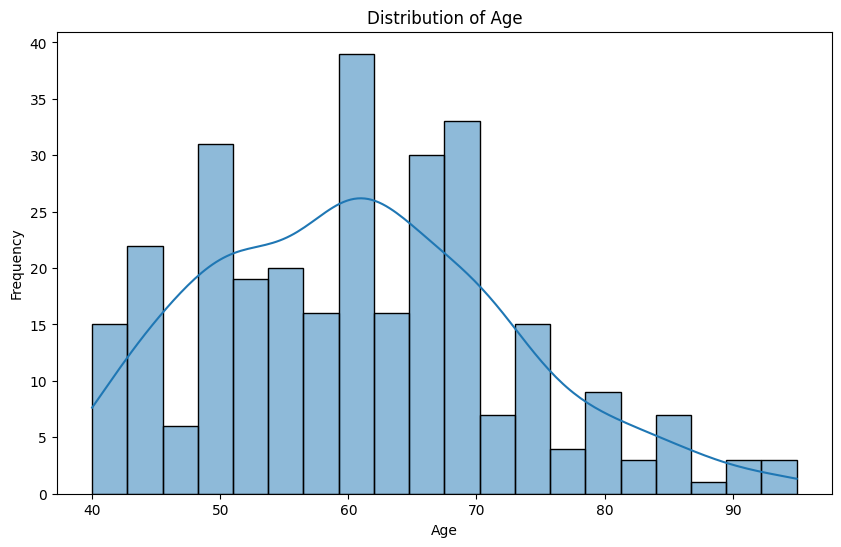

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


# Q2.How does the death rate vary with age ?

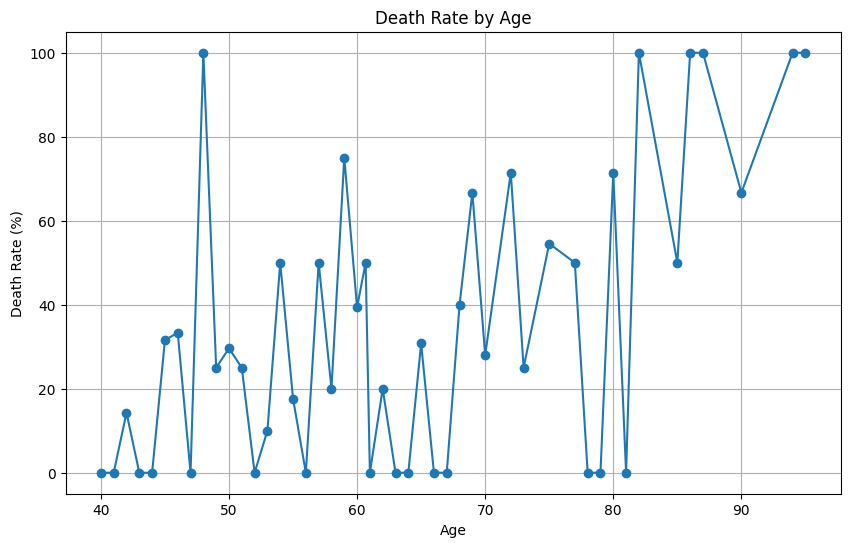

In [4]:
# Calculate death rate by age
death_rate_by_age = df.groupby('age')['DEATH_EVENT'].mean() * 100

# Plot death rate against age
plt.figure(figsize=(10, 6))
plt.plot(death_rate_by_age, marker='o')
plt.title('Death Rate by Age')
plt.xlabel('Age')
plt.ylabel('Death Rate (%)')
plt.grid(True)
plt.show()


# **Q3. Gender Distribution**

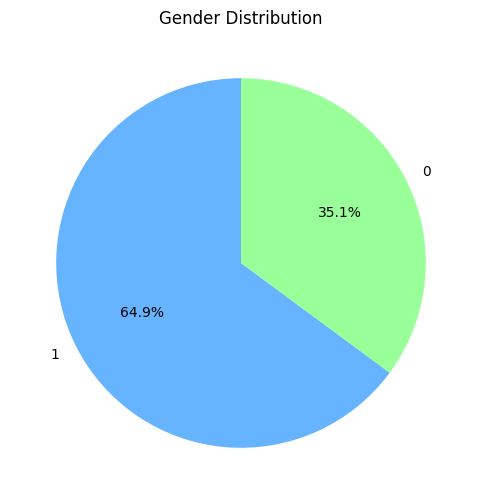

In [5]:
# Calculate percentage of male and female patients
gender_distribution = df['sex'].value_counts(normalize=True) * 100

# Plot gender distribution
plt.figure(figsize=(8, 6))
gender_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Gender Distribution')
plt.ylabel('')  # Hide the y-label
plt.show()


# *Q4. Platelet Count by Age Groups*

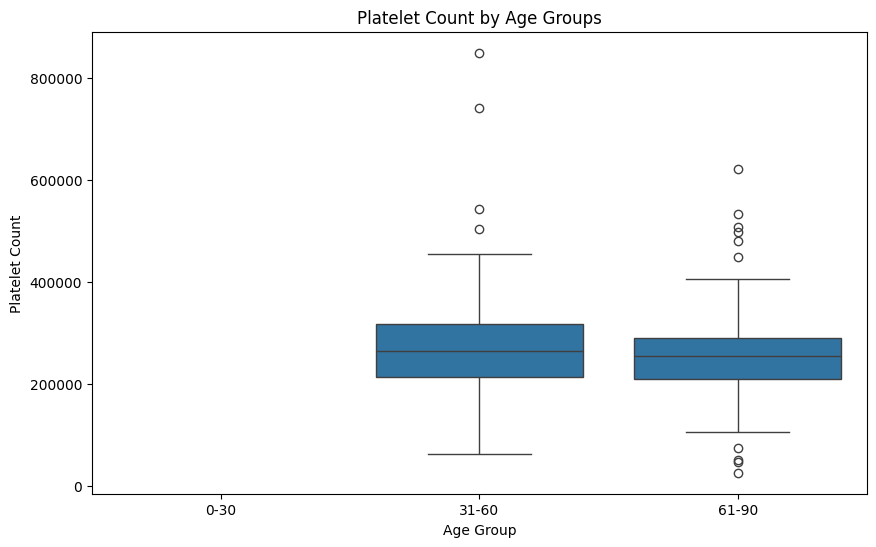

In [6]:
# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['0-30', '31-60', '61-90'])

# Plot platelet count by age groups
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='platelets', data=df)
plt.title('Platelet Count by Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Platelet Count')
plt.show()


# Q5. Correlation Between Creatinine and Sodium Levels

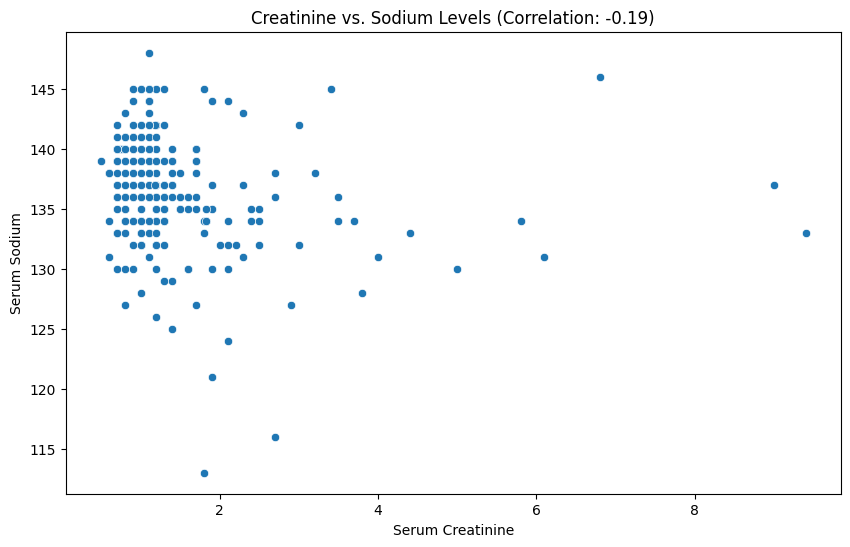

-0.1890952100911741

In [7]:
# Calculate correlation
creatinine_sodium_corr = df['serum_creatinine'].corr(df['serum_sodium'])

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='serum_creatinine', y='serum_sodium', data=df)
plt.title(f'Creatinine vs. Sodium Levels (Correlation: {creatinine_sodium_corr:.2f})')
plt.xlabel('Serum Creatinine')
plt.ylabel('Serum Sodium')
plt.show()

creatinine_sodium_corr


# Q6.Prevalence of High Blood Pressure by Gender

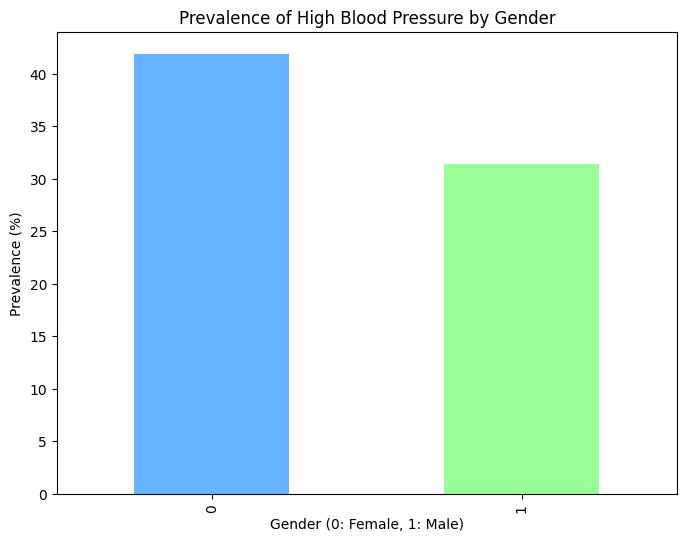

,high_blood_pressure
sex,
0,41.904762
1,31.443299


In [8]:
# Calculate prevalence of high blood pressure by gender
high_bp_by_gender = df.groupby('sex')['high_blood_pressure'].mean() * 100

# Plot the prevalence
plt.figure(figsize=(8, 6))
high_bp_by_gender.plot(kind='bar', color=['#66b3ff', '#99ff99'])
plt.title('Prevalence of High Blood Pressure by Gender')
plt.xlabel('Gender (0: Female, 1: Male)')
plt.ylabel('Prevalence (%)')
plt.show()

high_bp_by_gender


# **Q7. Smoking Habits and Heart Failure**

<Figure size 800x600 with 0 Axes>

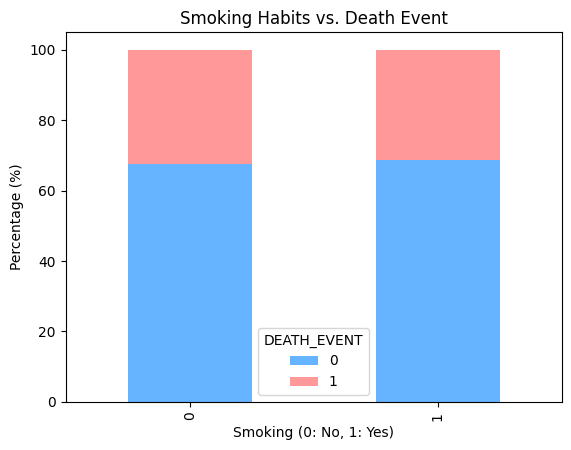

DEATH_EVENT,0,1
smoking,,
0,67.487685,32.512315
1,68.750000,31.250000


In [9]:
# Contingency table of smoking and death event
smoking_vs_death = pd.crosstab(df['smoking'], df['DEATH_EVENT'], normalize='index') * 100

# Plot the relationship
plt.figure(figsize=(8, 6))
smoking_vs_death.plot(kind='bar', stacked=True, color=['#66b3ff','#ff9999'])
plt.title('Smoking Habits vs. Death Event')
plt.xlabel('Smoking (0: No, 1: Yes)')
plt.ylabel('Percentage (%)')
plt.show()

smoking_vs_death


# **Q8. Death Event Distribution Across Age Groups**

<ipython-input-10-9b70565cb60b>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  death_event_by_age_group = df.groupby('age_group')['DEATH_EVENT'].mean() * 100


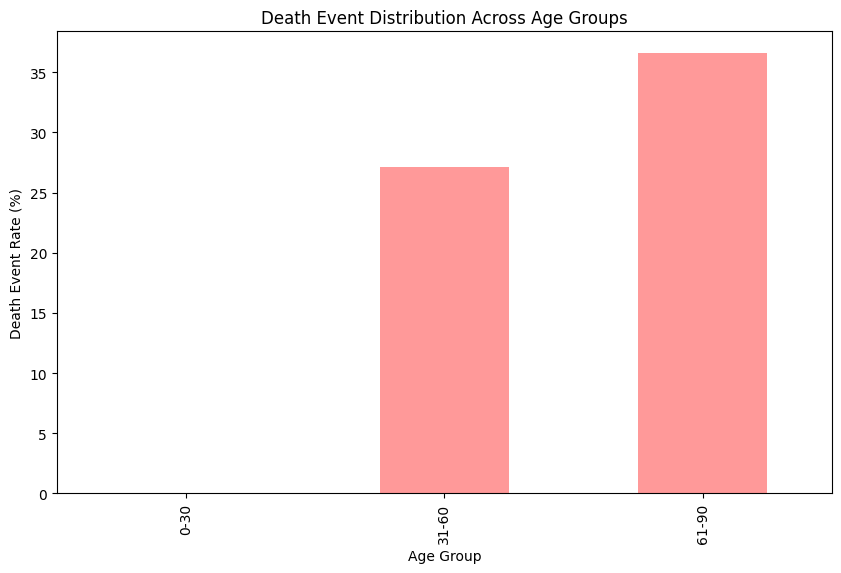

,DEATH_EVENT
age_group,
0-30,NaN
31-60,27.160494
61-90,36.567164


In [10]:
# Distribution of death events across age groups
death_event_by_age_group = df.groupby('age_group')['DEATH_EVENT'].mean() * 100

# Plot the distribution
plt.figure(figsize=(10, 6))
death_event_by_age_group.plot(kind='bar', color='#ff9999')
plt.title('Death Event Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Death Event Rate (%)')
plt.show()

death_event_by_age_group


# Q9.Ejection Fraction and Diabetes

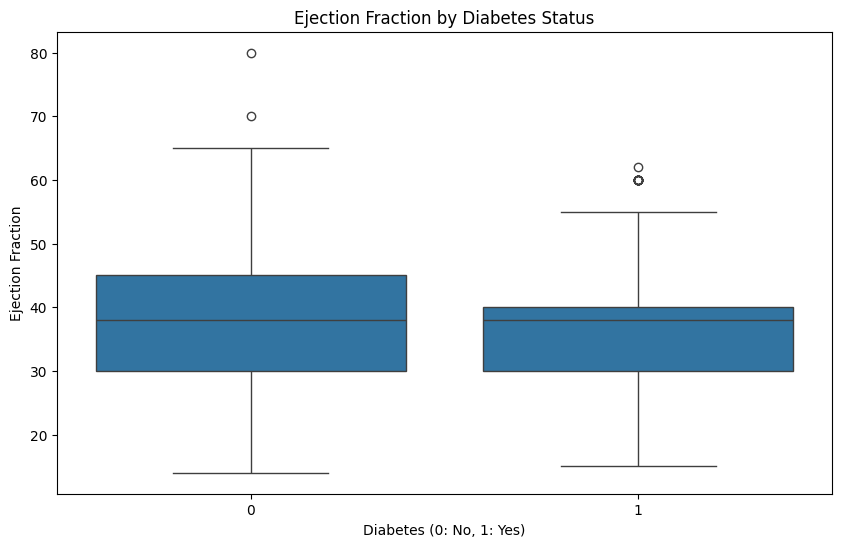

In [11]:
# Box plot of ejection fraction by diabetes status
plt.figure(figsize=(10, 6))
sns.boxplot(x='diabetes', y='ejection_fraction', data=df)
plt.title('Ejection Fraction by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Ejection Fraction')
plt.show()


# Q10.Serum Creatinine Levels Among Survivors and Non-Survivors

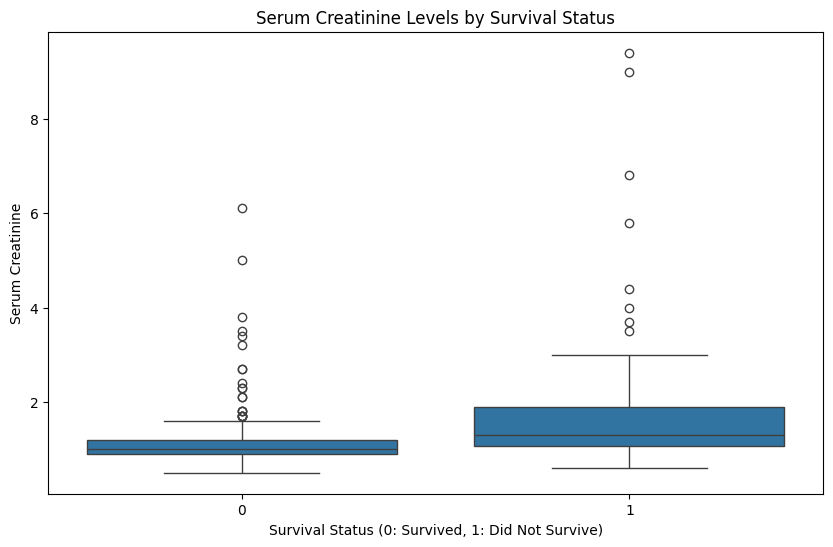

In [12]:
# Box plot of serum creatinine by survival status
plt.figure(figsize=(10, 6))
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
plt.title('Serum Creatinine Levels by Survival Status')
plt.xlabel('Survival Status (0: Survived, 1: Did Not Survive)')
plt.ylabel('Serum Creatinine')
plt.show()
